<a href="https://colab.research.google.com/github/Dineshkarthi006/ACTIVATION-FUNCTIONS-AND-OPTIMIZATION-ALGORITHMS-IN-DEEP-LEARNING/blob/main/ACTIVATION_FUNCTIONS_AND_OPTIMIZATION_ALGORITHMS_IN_DEEP_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PART A: VISUALIZATION OF ACTIVATION FUNCTIONS (Dineshkarthi S , 24BAD402)


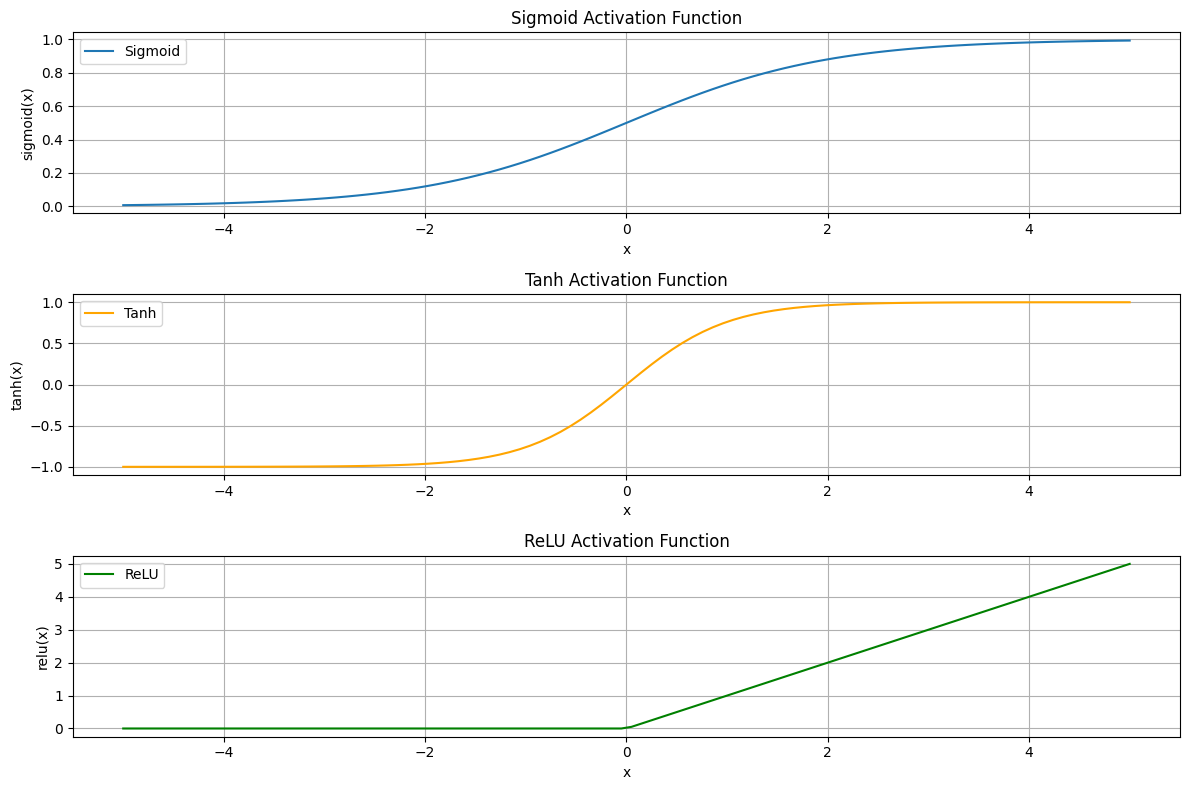

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh function
def tanh(x):
    return np.tanh(x)

# ReLU function
def relu(x):
    return np.maximum(0, x)

# Generate x values
x = np.linspace(-5, 5, 100)

# Plotting the activation functions
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.title('Sigmoid Activation Function')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(x, tanh(x), label='Tanh', color='orange')
plt.title('Tanh Activation Function')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(x, relu(x), label='ReLU', color='green')
plt.title('ReLU Activation Function')
plt.xlabel('x')
plt.ylabel('relu(x)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## PART B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize pixel values to [0, 1]

print(f"Training data shape: {x_train.shape}, {y_train.shape}")
print(f"Testing data shape: {x_test.shape}, {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28), (60000,)
Testing data shape: (10000, 28, 28), (10000,)


### Define a common ANN architecture and training function

In [3]:
def create_model(activation_function):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation_function),
        Dense(64, activation=activation_function),
        Dense(10, activation='softmax')  # Output layer for 10 classes
    ])
    return model

def train_and_evaluate_model(model, x_train, y_train, x_test, y_test, epochs=10, batch_size=32):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_test, y_test),
                        verbose=0)
    return history

### Train models with different activation functions

In [4]:
histories = {}
activation_functions = ['sigmoid', 'tanh', 'relu']

for act_fn in activation_functions:
    print(f"Training model with {act_fn} activation...")
    model = create_model(act_fn)
    history = train_and_evaluate_model(model, x_train, y_train, x_test, y_test)
    histories[act_fn] = history
    print(f"Finished training for {act_fn}.")

Training model with sigmoid activation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Finished training for sigmoid.
Training model with tanh activation...
Finished training for tanh.
Training model with relu activation...
Finished training for relu.


### Visualize and compare performance

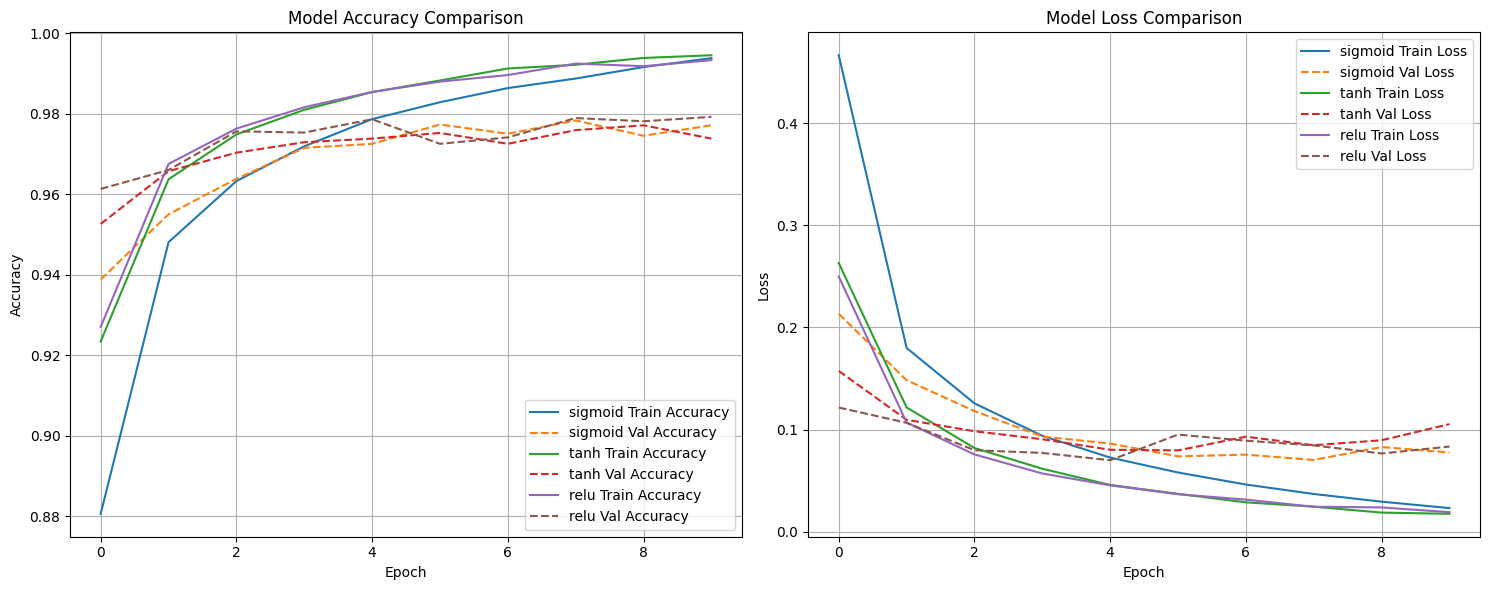


--- Performance Summary ---

SIGMOID Activation:
  Final Validation Accuracy: 0.9771
  Final Validation Loss: 0.0776
  Approx. Epochs to min Val Loss: 8

TANH Activation:
  Final Validation Accuracy: 0.9738
  Final Validation Loss: 0.1053
  Approx. Epochs to min Val Loss: 6

RELU Activation:
  Final Validation Accuracy: 0.9792
  Final Validation Loss: 0.0834
  Approx. Epochs to min Val Loss: 5


In [5]:
plt.figure(figsize=(15, 6))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
for act_fn, history in histories.items():
    plt.plot(history.history['accuracy'], label=f'{act_fn} Train Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{act_fn} Val Accuracy', linestyle='--')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
for act_fn, history in histories.items():
    plt.plot(history.history['loss'], label=f'{act_fn} Train Loss')
    plt.plot(history.history['val_loss'], label=f'{act_fn} Val Loss', linestyle='--')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Performance Summary ---")
for act_fn, history in histories.items():
    final_val_acc = history.history['val_accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    print(f"\n{act_fn.upper()} Activation:")
    print(f"  Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"  Final Validation Loss: {final_val_loss:.4f}")
    # Calculate epochs to convergence (simplified: where validation loss plateaus or starts increasing)
    # This is a heuristic; more robust methods exist.
    val_loss_curve = history.history['val_loss']
    min_val_loss_epoch = np.argmin(val_loss_curve) + 1 # +1 because epochs are 1-indexed
    print(f"  Approx. Epochs to min Val Loss: {min_val_loss_epoch}")

## PART C: COMPARISON OF OPTIMIZATION ALGORITHMS

### Define a training function for different optimizers

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
import matplotlib.pyplot as plt
import numpy as np

# Reuse the create_model function from Part B, setting ReLU as the default activation for hidden layers
def create_model_for_optimizer(activation_function='relu'):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation_function),
        Dense(64, activation=activation_function),
        Dense(10, activation='softmax')
    ])
    return model

def train_and_evaluate_optimizer_model(model, optimizer, x_train, y_train, x_test, y_test, epochs=10, batch_size=32):
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_test, y_test),
                        verbose=0)
    return history

### Train models with different optimization algorithms

In [7]:
optimizer_histories = {}

# Define optimizers with their common learning rates
optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'SGD_Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(learning_rate=0.001),
    'Adam': Adam(learning_rate=0.001)
}

# Load and preprocess the MNIST dataset (if not already loaded in the current session)
# This check ensures it's only loaded once if the kernel restarts or is run out of order.
try:
    if 'x_train' not in locals() or 'x_test' not in locals():
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        x_train, x_test = x_train / 255.0, x_test / 255.0
        print("MNIST dataset reloaded for optimizers comparison.")
except NameError: # If `tf` itself is not imported
    import tensorflow as tf
    from tensorflow.keras.datasets import mnist
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0
    print("MNIST dataset loaded for optimizers comparison.")

for opt_name, optimizer_instance in optimizers.items():
    print(f"Training model with {opt_name} optimizer...")
    model = create_model_for_optimizer()
    history = train_and_evaluate_optimizer_model(model, optimizer_instance, x_train, y_train, x_test, y_test)
    optimizer_histories[opt_name] = history
    print(f"Finished training for {opt_name}.")

Training model with SGD optimizer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Finished training for SGD.
Training model with SGD_Momentum optimizer...
Finished training for SGD_Momentum.
Training model with RMSprop optimizer...
Finished training for RMSprop.
Training model with Adam optimizer...
Finished training for Adam.


### Visualize and compare optimizer performance

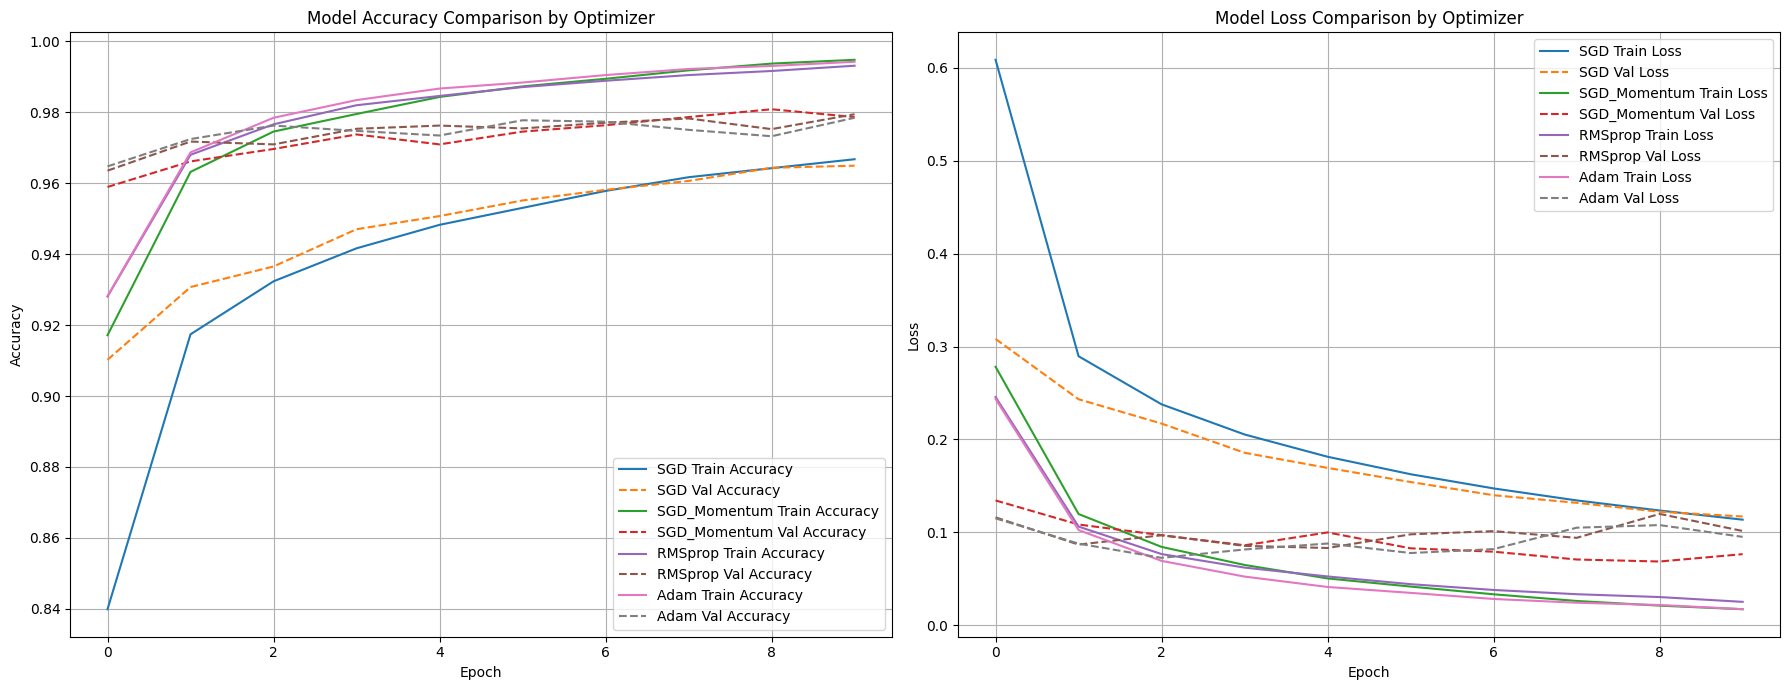


--- Optimizer Performance Summary ---

SGD Optimizer:
  Final Training Accuracy: 0.9667
  Final Validation Accuracy: 0.9649
  Final Training Loss: 0.1137
  Final Validation Loss: 0.1171
  Approx. Epochs to min Val Loss: 10

SGD_Momentum Optimizer:
  Final Training Accuracy: 0.9947
  Final Validation Accuracy: 0.9786
  Final Training Loss: 0.0173
  Final Validation Loss: 0.0766
  Approx. Epochs to min Val Loss: 9

RMSprop Optimizer:
  Final Training Accuracy: 0.9931
  Final Validation Accuracy: 0.9794
  Final Training Loss: 0.0252
  Final Validation Loss: 0.1015
  Approx. Epochs to min Val Loss: 5

Adam Optimizer:
  Final Training Accuracy: 0.9942
  Final Validation Accuracy: 0.9784
  Final Training Loss: 0.0174
  Final Validation Loss: 0.0952
  Approx. Epochs to min Val Loss: 3


In [8]:
plt.figure(figsize=(18, 7))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
for opt_name, history in optimizer_histories.items():
    plt.plot(history.history['accuracy'], label=f'{opt_name} Train Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{opt_name} Val Accuracy', linestyle='--')
plt.title('Model Accuracy Comparison by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
for opt_name, history in optimizer_histories.items():
    plt.plot(history.history['loss'], label=f'{opt_name} Train Loss')
    plt.plot(history.history['val_loss'], label=f'{opt_name} Val Loss', linestyle='--')
plt.title('Model Loss Comparison by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Optimizer Performance Summary ---")
for opt_name, history in optimizer_histories.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    print(f"\n{opt_name} Optimizer:")
    print(f"  Final Training Accuracy: {final_train_acc:.4f}")
    print(f"  Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"  Final Training Loss: {final_train_loss:.4f}")
    print(f"  Final Validation Loss: {final_val_loss:.4f}")

    # Approximate convergence speed by finding the epoch with minimum validation loss
    val_loss_curve = history.history['val_loss']
    min_val_loss_epoch = np.argmin(val_loss_curve) + 1
    print(f"  Approx. Epochs to min Val Loss: {min_val_loss_epoch}")

## PART D: DEEP LEARNING EXPERIMENT MANAGEMENT

### 1. Mount Google Drive

In [9]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a directory for models and notebooks if it doesn't exist
drive_path = '/content/drive/MyDrive/Colab_DL_Experiments'
if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f"Created directory: {drive_path}")
else:
    print(f"Directory already exists: {drive_path}")

Mounted at /content/drive
Created directory: /content/drive/MyDrive/Colab_DL_Experiments


### 2. Save Trained Models

In [10]:
import tensorflow as tf

# Let's use the Adam-trained model for demonstration
# First, re-create and train the Adam model to ensure it's in scope if kernel restarted
# Or, retrieve it from the optimizer_histories if the kernel is still running.

# If you need to re-run this cell independently and 'optimizer_histories' is not defined,
# you would need to run the Part C cells again or create a fresh model.

# For demonstration, let's train a new model using Adam for saving.
# If the 'optimizer_histories' from Part C is still available, we can just use the model that was trained with Adam.

# Assuming `x_train`, `y_train`, `x_test`, `y_test` are already loaded from previous parts

print("Re-training a sample model with Adam for saving demonstration...")
model_to_save = create_model_for_optimizer('relu') # Using ReLU as chosen in Part C for optimizer comparison
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
history_adam_for_save = train_and_evaluate_optimizer_model(model_to_save, adam_optimizer, x_train, y_train, x_test, y_test, epochs=5) # Shorter epochs for demo
print("Sample model re-trained.")

# Define the path to save the model in Google Drive
model_save_path = os.path.join(drive_path, 'my_mnist_adam_model.keras') # .keras is the recommended universal format

# Save the model
model_to_save.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# You can also save a specific history object if needed (e.g., as a pickle file)
# import pickle
# history_save_path = os.path.join(drive_path, 'adam_history.pkl')
# with open(history_save_path, 'wb') as f:
#     pickle.dump(history_adam_for_save.history, f)
# print(f"History saved to: {history_save_path}")

Re-training a sample model with Adam for saving demonstration...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sample model re-trained.
Model saved to: /content/drive/MyDrive/Colab_DL_Experiments/my_mnist_adam_model.keras


### 3. Create a GitHub Repository and Upload Notebooks (Instructions)

Integrating Google Colab notebooks with GitHub is crucial for version control and collaboration.

**Steps to follow:**

1.  **Create a New GitHub Repository:**
    *   Go to [GitHub](https://github.com/).
    *   Click on the '+' sign in the top right corner and select 'New repository'.
    *   Give your repository a meaningful name (e.g., `DL_Activation_Optimizer_Study`).
    *   (Optional but Recommended) Add a brief description.
    *   Choose whether it's public or private.
    *   Initialize the repository with a `README.md` file (this is very useful).
    *   Click 'Create repository'.

2.  **Save your Colab Notebook to GitHub:**
    *   In your Colab notebook, go to `File` -> `Save a copy in GitHub...`.
    *   You might need to authorize Colab to access your GitHub account.
    *   Select the repository you just created.
    *   Provide a commit message (e.g., "Initial commit: Activation and Optimizer Study notebook").
    *   Click 'OK'.

3.  **Commit Changes and Maintain Version History:**
    *   As you make changes to your Colab notebook, you can save new versions to GitHub.
    *   Go to `File` -> `Save a copy in GitHub...` again.
    *   Colab will prompt you to commit changes to the same repository. Provide a descriptive commit message for each set of changes.
    *   Alternatively, you can manually commit using Git commands in a Colab code cell (for advanced users) after cloning the repo to Colab, but `File -> Save a copy in GitHub` is simpler for notebooks.

4.  **Document the Experiment using `README.md`:**
    *   The `README.md` file in your GitHub repository is essential for documenting your project.
    *   You can edit the `README.md` directly on GitHub's website or clone the repository to your Colab environment or local machine to edit it.
    *   **What to include in `README.md`:**
        *   **Project Title:** E.g., "Comparative Study of Activation Functions and Optimization Algorithms"
        *   **Aim & Objectives:** Copy-paste from your project description.
        *   **Software Requirements:** List Python, TensorFlow/PyTorch, Google Colab, GitHub, Matplotlib.
        *   **Procedure Summary:** Briefly describe Part A, B, C, and D.
        *   **Key Findings/Results:** Summarize the main conclusions from your activation function and optimizer comparisons.
        *   **Instructions:** How to run the notebook, dependencies, etc.
        *   **Screenshots:** You can include screenshots of key plots (like the ones generated in Part A, B, and C) for quick visualization.
        *   **Student Details:** (If required) Include your name and roll number.

By following these steps, you will effectively manage your deep learning experiment, maintain version control, and ensure reproducibility.